In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [4]:
df = pd.read_csv("AIML Dataset.csv")

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.shape

(6362620, 11)

In [12]:
#checking the percentage of the frauds here !
round(df["isFraud"].value_counts()[1] / df.shape[0] * 100, 2)
#here we found that the percentage of frauds is 0.13% only

np.float64(0.13)

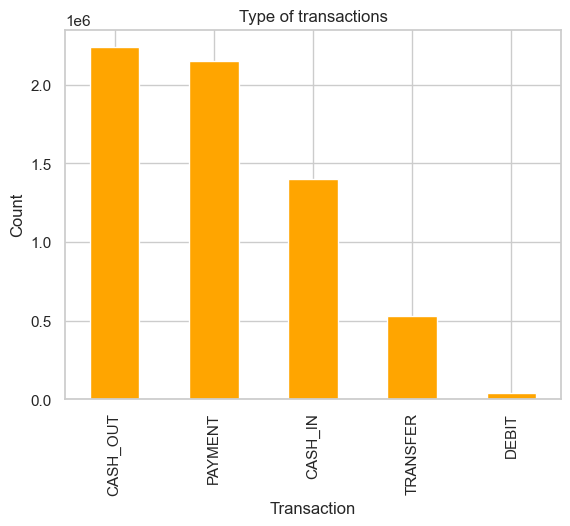

In [13]:
#now we will visualize the data
df["type"].value_counts().plot(kind="bar", title="Type of transactions", color = "orange")
plt.xlabel("Transaction")
plt.ylabel("Count")
plt.show()

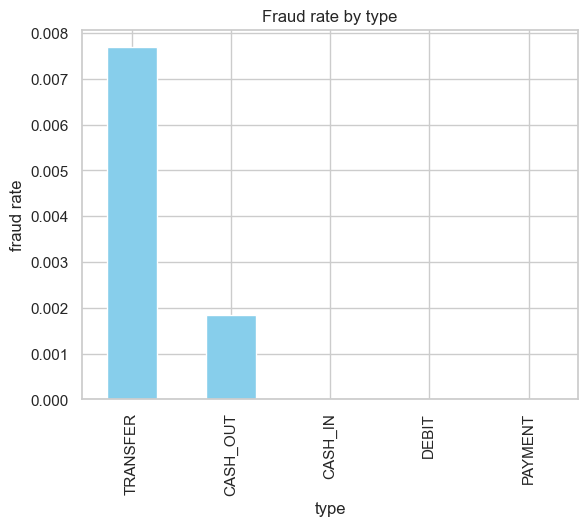

In [14]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud rate by type", color="skyblue")
plt.ylabel("fraud rate")
plt.show()

In [15]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

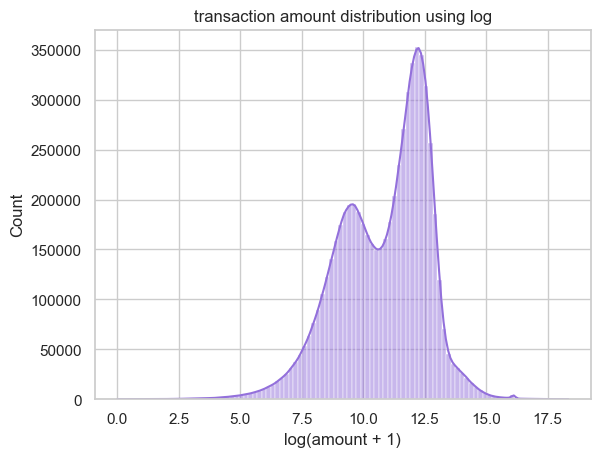

In [16]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde= True, color= "mediumpurple")
plt.title("transaction amount distribution using log")
plt.xlabel("log(amount + 1)")
plt.show()

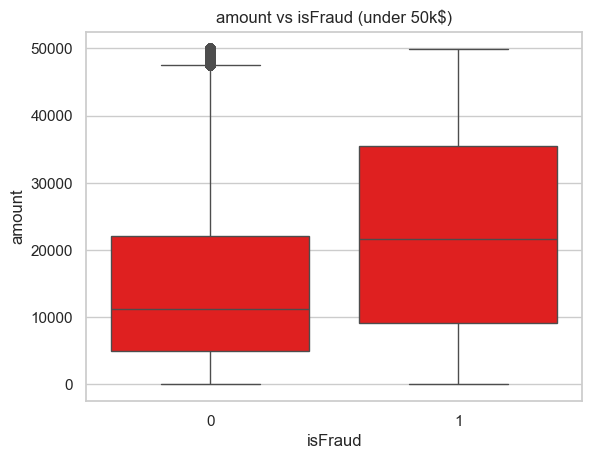

In [17]:
sns.boxplot(df[df["amount"] < 50000], x="isFraud", y="amount", color= "red")
plt.title("amount vs isFraud (under 50k$)")
plt.show()

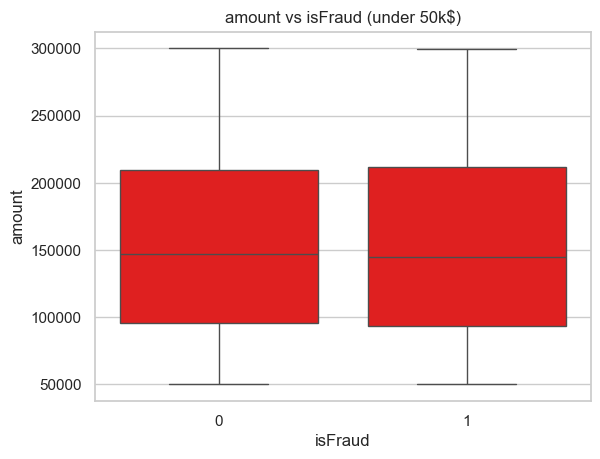

In [18]:
sns.boxplot(df[(df["amount"] > 50000) & (df["amount"]<300000)], x="isFraud", y="amount", color= "red")
plt.title("amount vs isFraud (under 50k$)")
plt.show()

In [19]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [20]:
df["balanceDiffOrg"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"]= df["oldbalanceDest"] - df["newbalanceDest"]
(df["balanceDiffOrg"]<0).sum()


np.int64(1399253)

In [21]:
(df["balanceDiffDest"]<0).sum()

np.int64(2806464)

In [22]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


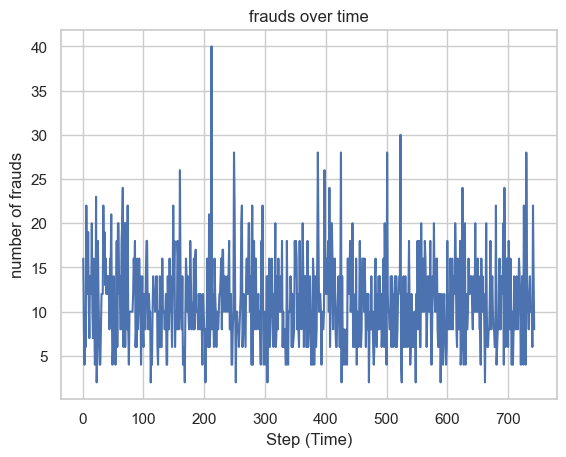

In [23]:
frauds_per_step = df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per step")
plt.xlabel("Step (Time)")
plt.ylabel("number of frauds")
plt.title("frauds over time")
plt.grid(True)
plt.show()

In [24]:
df.drop(columns="step", inplace=True)

In [25]:
df.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [26]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [27]:
top_receivers= df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [28]:
fraud_users = df[df["isFraud"]==1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [29]:
fraud_receivers = df[df["isFraud"]==1]["nameDest"].value_counts().head(10)
fraud_receivers

nameDest
C967226405     2
C1601170327    2
C650699445     2
C105660024     2
C1981613973    2
C803116137     2
C505532836     2
C964377943     2
C200064275     2
C1259079602    2
Name: count, dtype: int64

In [30]:
fraud_types= df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

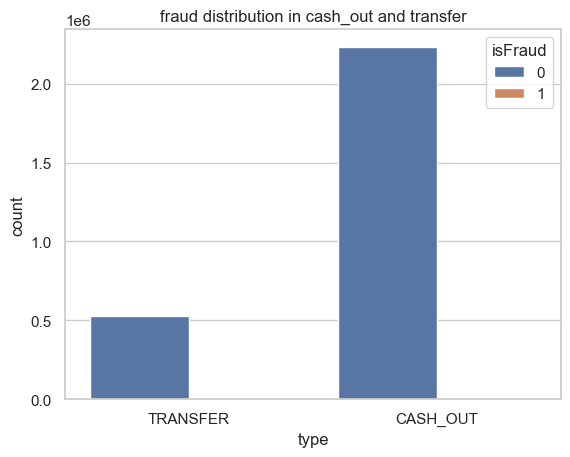

In [31]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("fraud distribution in cash_out and transfer")
plt.show()

In [32]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrg', 'balanceDiffDest'],
      dtype='object')

In [33]:
corr= df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


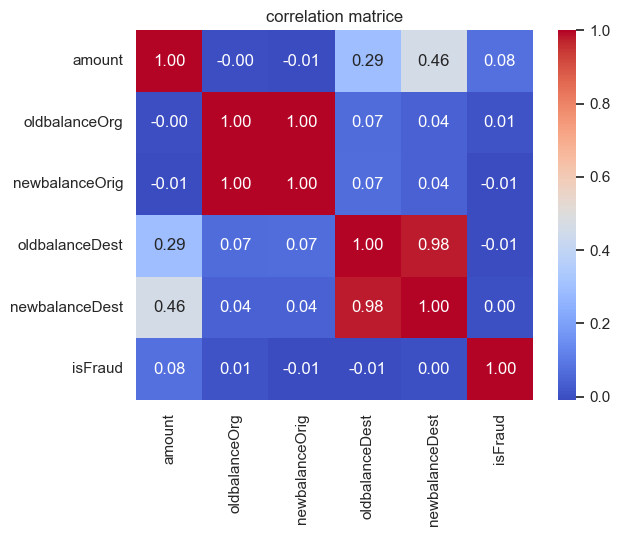

In [34]:
sns.heatmap(corr, annot=True, cmap= "coolwarm", fmt=".2f")
plt.title("correlation matrice")
plt.show()

In [35]:
zero_after_transfer = df[(df["oldbalanceOrg"]>0) & (df["newbalanceOrig"]==0)& (df["type"].isin(["TRANSFER", "CASH_OUT"]))]
len(zero_after_transfer)

1188074

In [36]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-2712905.89


In [37]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [38]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [40]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [41]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis=1)    

In [42]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [43]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [44]:
y= df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

In [45]:
X_train, X_test,y_train, y_test =train_test_split(X,y, test_size=0.3, stratify=y)
 

In [46]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric), ("cat", OneHotEncoder(drop="first"),categorical )], remainder="drop")

In [47]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [48]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [49]:
y_pred = pipeline.predict(X_test)

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [51]:
print(confusion_matrix(y_test, y_pred))

[[1802204  104118]
 [    155    2309]]


In [52]:
#Comment
"""-----------------------------------------------------------"""
""" 
-As we can see here the amount of the FP is super huge this is why the precision if extremely low (2%)
-This only means that our recall is capturing a lot of innocent people and label them as fraud
"""

' \n-As we can see here the amount of the FP is super huge this is why the precision if extremely low (2%)\n-This only means that our recall is capturing a lot of innocent people and label them as fraud\n'

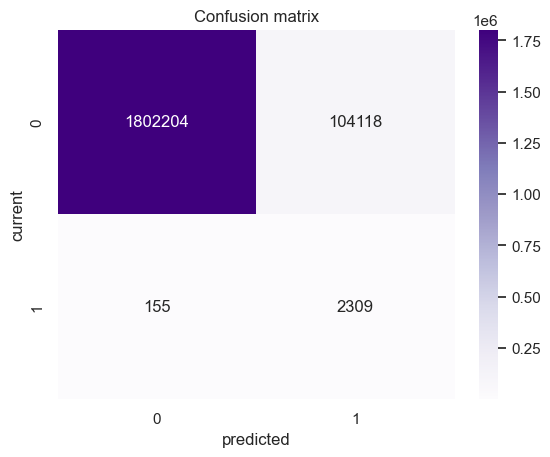

In [53]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt="d", cmap="Purples")
plt.title("Confusion matrix")
plt.xlabel("predicted")
plt.ylabel("current")
plt.show()

In [54]:
""" Comment:
        -Now lets change from the predict() to proba(): The goal here is to be more stricted with the model and oly if its 99% sure is fraud he can count it as fraud
"""

' Comment:\n        -Now lets change from the predict() to proba(): The goal here is to be more stricted with the model and oly if its 99% sure is fraud he can count it as fraud\n'

In [55]:
y_probs = pipeline.predict_proba(X_test)[:,1]
y_pred_new= (y_probs >0.99 ).astype(int)
print(classification_report(y_test, y_pred_new))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.33      0.59      0.42      2464

    accuracy                           1.00   1908786
   macro avg       0.66      0.79      0.71   1908786
weighted avg       1.00      1.00      1.00   1908786



In [56]:
confusion_matrix(y_test, y_pred_new)

array([[1903308,    3014],
       [   1010,    1454]])

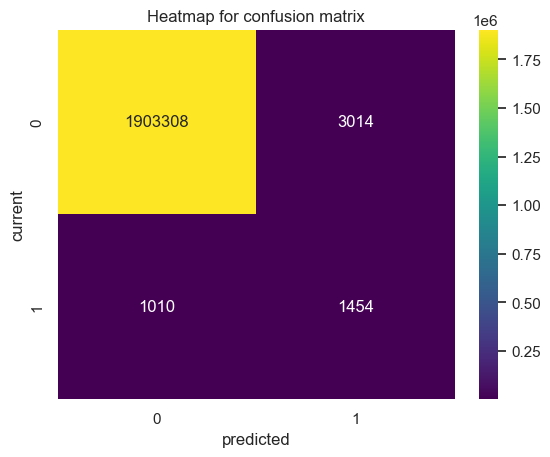

In [57]:
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap="viridis")
plt.title("Heatmap for confusion matrix")
plt.xlabel("predicted")
plt.ylabel("current")
plt.show()

In [58]:
"""Comment:
        -Now we have increased the precision to 31% instead of 2%
        -But the recall has dropped from 94% to 62% leading to a signficant augmentation in the number of uncaught frauds
        -Here we can confidently say that the logisitic regression has reached its limit 
        -My solution: its to switch to another machine learning model (in my case im going to use xgboost)
"""

'Comment:\n        -Now we have increased the precision to 31% instead of 2%\n        -But the recall has dropped from 94% to 62% leading to a signficant augmentation in the number of uncaught frauds\n        -Here we can confidently say that the logisitic regression has reached its limit \n        -My solution: its to switch to another machine learning model (in my case im going to use xgboost)\n'

In [59]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [60]:
from xgboost import XGBClassifier
ratio= 1906322/2464
pipeline = Pipeline(
    [
        ("prep", preprocessor),
        ("clf", XGBClassifier(scale_pos_weight=ratio,   n_estimator=100, learning_rate=0.1))
    ]
)


In [61]:
importances = pipeline.named_steps['clf'].feature_importances_
features = pipeline.named_steps['prep'].get_feature_names_out()
plt.barh(features, importances)
plt.title("What features matter most for Fraud detection?")
plt.xlabel("importance")
plt.show()

NotFittedError: need to call fit or load_model beforehand

In [ ]:
"""Comment:
    -As we can see our XGboost is finding its own pattern its looking for the accounts with a newbalanceorig=0
    -But there's still a vulnerability in this pattern because what if the fraudulent is letting in newbalanceorig=1$, the model an tell its not a scam
"""

"Comment:\n    -As we can see our XGboost is finding its own pattern its looking for the accounts with a newbalanceorig=0\n    -But there's still a vulnerability in this pattern because what if the fraudulent is letting in newbalanceorig=1$, the model an tell its not a scam\n"

In [ ]:
df["is_emptied"] = ((df["newbalanceOrig"] == 0) & (df["oldbalanceOrg"] > 0)).astype(int)

In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrg', 'balanceDiffDest', 'is_emptied'],
      dtype='object')

In [ ]:
X= df.drop(["isFraud","nameOrig","nameDest"], axis=1)
y= df['isFraud']

In [ ]:
X_train, X_test, y_train,y_test= train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 5090096
Testing set size: 1272524


In [ ]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [ ]:
y_pred_xgb= pipeline.predict(X_test)
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.17      1.00      0.29      1643

    accuracy                           0.99   1272524
   macro avg       0.59      1.00      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524



In [ ]:
print(confusion_matrix(y_test, y_pred_xgb))

[[1262898    7983]
 [      4    1639]]


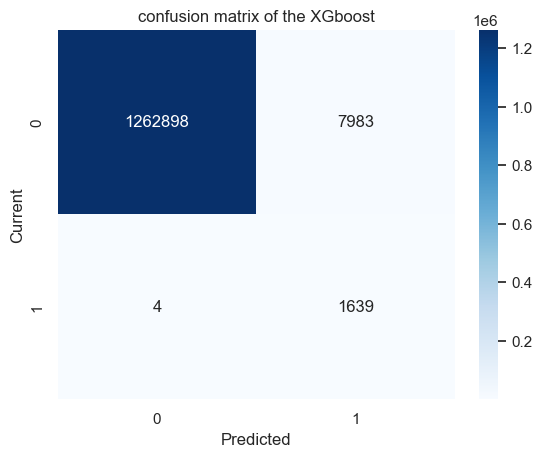

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap="Blues")
plt.title("confusion matrix of the XGboost")
plt.xlabel("Predicted")
plt.ylabel("Current")
plt.show()

In [ ]:
"""comment:
    -for a threshold of 51% we can say our model did a great job even for a 17% precision (only 4 FN)
    -now i'll move on to the last threshold tuning and see if the precision is getting higher 
"""

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.92      0.77      0.84      1643

    accuracy                           1.00   1272524
   macro avg       0.96      0.89      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



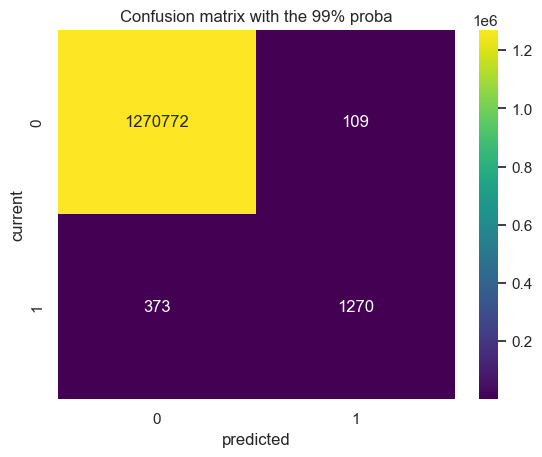

In [ ]:
y_probs_xgb = pipeline.predict_proba(X_test)[:,1]
y_pred_new_xgb= (y_probs_xgb >0.99 ).astype(int)
print(classification_report(y_test, y_pred_new_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_new_xgb), annot=True, fmt='d', cmap="viridis")
plt.title("Confusion matrix with the 99% proba")
plt.xlabel("predicted")
plt.ylabel("current")
plt.show()


In [ ]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import joblib 
joblib.dump(pipeline, 'fraud_model.pkl')

['fraud_model.pkl']